# Exploratory Data Analysis of Customer Sentiment Analysis
##### Ömer Faruk Merey - Middle East Technical University

This notebook explores the BrownBox customer service conversation dataset to understand its structure, class distribution, and feature relationships before building an attention-based sentiment classifier.

**Dataset:** 970 train + 30 test customer-agent conversations labeled as positive, negative, or neutral.

**Key questions:**
- How are the sentiment classes distributed? Is there class imbalance?
- Is there a correlation between metadata features (issue area, complexity, agent experience) and sentiment?
- What do the conversations look like in terms of length and structure?

In [1]:
import pandas as pd

train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')

In [2]:
train_df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


In [3]:
test_df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Shopping,Pricing and Discounts,Discounts through exchange offers,Pricing and Discounts -> Discounts through exc...,negative,Appliances,Hand Blender,less,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
1,Login and Account,Account Reactivation and Deactivation,Reactivating an inactive account,Account Reactivation and Deactivation -> React...,negative,Men/Women/Kids,Wrist Watch,medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
2,Cancellations and returns,Cash on Delivery (CoD) Refunds,Refund timelines for Cash on Delivery returns,Cash on Delivery (CoD) Refunds -> Refund timel...,negative,Appliances,Induction Cooktop,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
3,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as deli...,negative,Men/Women/Kids,Sunglas,high,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
4,Cancellations and returns,Pickup and Shipping,Reimbursement of courier charges for return,Pickup and Shipping -> Reimbursement of courie...,negative,Electronics,Computer Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...


## 1. Dataset Overview
Looking at simple aspects

In [4]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}\n")

overview = pd.DataFrame({
    'Column': train_df.columns,
    'Type': train_df.dtypes.values,
    'Train Missing': train_df.isnull().sum().values,
    'Test Missing': test_df.isnull().sum().values,
    'Train Unique': train_df.nunique().values,
    'Test Unique': test_df.nunique().values
})
overview

Train shape: (970, 11)
Test shape:  (30, 11)



,Column,Type,Train Missing,Test Missing,Train Unique,Test Unique
0,issue_area,object,0,0,6,6
1,issue_category,object,0,0,40,16
2,issue_sub_category,object,0,0,109,22
3,issue_category_sub_category,object,0,0,109,22
4,customer_sentiment,object,0,0,3,3
5,product_category,object,0,0,3,3
6,product_sub_category,object,0,0,50,21
7,issue_complexity,object,0,0,3,3
8,agent_experience_level,object,0,0,3,3
9,agent_experience_level_desc,object,0,0,3,3


## 2. Target Distribution (customer_sentiment)
Class imbalance check and it's distribution.

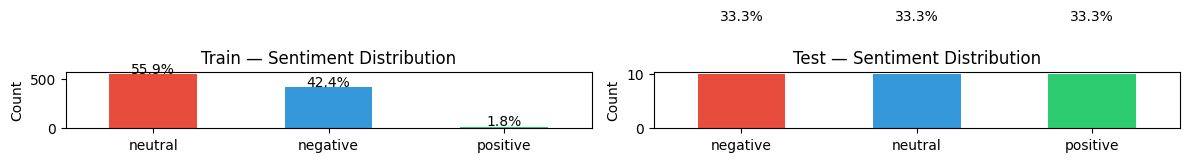

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = df['customer_sentiment'].value_counts()
    counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db', '#2ecc71'][:len(counts)])
    ax.set_title(f'{name} — Sentiment Distribution')
    ax.set_ylabel('Count')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

    for i, (val, count) in enumerate(counts.items()):
        ax.text(i, count + 10, f'{count/len(df)*100:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Categorical Feature Distributions
Unique values and top categories for each feature.

In [6]:
cat_cols = ['issue_area', 'issue_complexity', 'agent_experience_level', 'product_category']

rows = []
for col in cat_cols:
    for val, count in train_df[col].value_counts().items():
        rows.append({'Feature': col, 'Value': val, 'Count': count, '%': round(count / len(train_df) * 100, 1)})

cat_dist = pd.DataFrame(rows)
cat_dist.pivot_table(index=['Feature', 'Value'], values=['Count', '%'], aggfunc='first').sort_values(
    ['Feature', 'Count'], ascending=[True, False]
)

%  Count
Feature                Value                                 
agent_experience_level junior                     50.5    490
                       experienced                34.9    339
                       inexperienced              14.5    141
issue_area             Cancellations and returns  28.6    277
                       Order                      26.6    258
                       Login and Account          15.4    149
                       Shopping                   11.6    113
                       Warranty                   10.6    103
                       Shipping                    7.2     70
issue_complexity       less                       48.7    472
                       medium                     42.9    416
                       high                        8.5     82
product_category       Appliances                 46.8    454
                       Electronics                30.2    293
                       Men/Women/Kids             23.0    223

## 4. Sentiment vs Key Features
How does sentiment relate to issue complexity and agent experience?

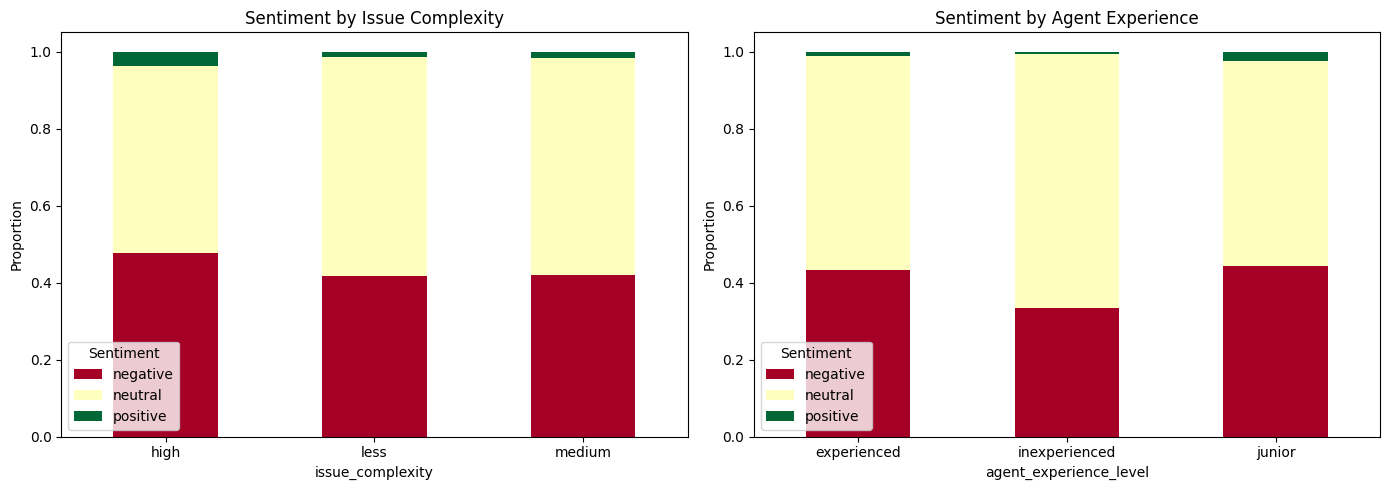

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment vs Issue Complexity
pd.crosstab(train_df['issue_complexity'], train_df['customer_sentiment'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn'
)
axes[0].set_title('Sentiment by Issue Complexity')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Sentiment vs Agent Experience
pd.crosstab(train_df['agent_experience_level'], train_df['customer_sentiment'], normalize='index').plot(
    kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn'
)
axes[1].set_title('Sentiment by Agent Experience')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()

## 5. Conversation Length Analysis
Due to the model, we need to check the conversation length because of it's effect on tokenization and model performance.

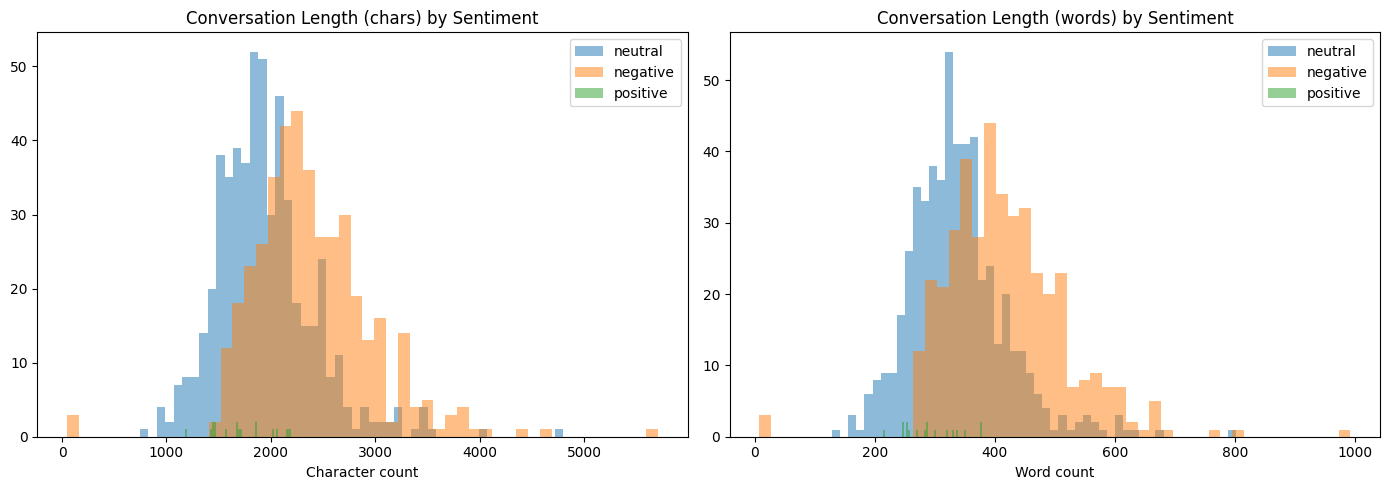

,conv_length_mean,conv_length_std,conv_length_min,conv_length_median,conv_length_max,conv_word_count_mean,conv_word_count_std,conv_word_count_min,conv_word_count_median,conv_word_count_max
customer_sentiment,,,,,,,,,,
negative,2395.5,580.2,46,2321.0,5708,417.7,101.4,8,406.0,992
neutral,1940.8,467.5,745,1888.5,4801,337.8,80.6,129,329.0,802
positive,1702.7,288.0,1173,1670.0,2190,294.0,48.2,213,286.0,378


In [8]:
train_df['conv_length'] = train_df['conversation'].str.len()
train_df['conv_word_count'] = train_df['conversation'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sentiment in train_df['customer_sentiment'].unique():
    subset = train_df[train_df['customer_sentiment'] == sentiment]
    axes[0].hist(subset['conv_length'], bins=50, alpha=0.5, label=sentiment)
axes[0].set_title('Conversation Length (chars) by Sentiment')
axes[0].set_xlabel('Character count')
axes[0].legend()

for sentiment in train_df['customer_sentiment'].unique():
    subset = train_df[train_df['customer_sentiment'] == sentiment]
    axes[1].hist(subset['conv_word_count'], bins=50, alpha=0.5, label=sentiment)
axes[1].set_title('Conversation Length (words) by Sentiment')
axes[1].set_xlabel('Word count')
axes[1].legend()

plt.tight_layout()
plt.show()

conv_stats = train_df.groupby('customer_sentiment')[['conv_length', 'conv_word_count']].agg(
    ['mean', 'std', 'min', 'median', 'max']
).round(1)
conv_stats.columns = [f'{col}_{stat}' for col, stat in conv_stats.columns]
conv_stats

## 6. Sentiment vs All Categorical Features
Checking correlation between every categorical feature and the target.

In [9]:
from scipy.stats import chi2_contingency
import numpy as np

cat_features = ['issue_area', 'issue_complexity', 'agent_experience_level',
                'product_category', 'issue_category', 'product_sub_category']

chi2_results = []
for col in cat_features:
    ct = pd.crosstab(train_df[col], train_df['customer_sentiment'])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0
    chi2_results.append({'Feature': col, 'Chi2': round(chi2, 2), 'p-value': round(p, 4), "Cramér's V": round(cramers_v, 3)})

chi2_df = pd.DataFrame(chi2_results).sort_values("Cramér's V", ascending=False).reset_index(drop=True)
chi2_df

,Feature,Chi2,p-value,Cramér's V
0,issue_category,1059.21,0.0000,0.739
1,issue_area,168.89,0.0000,0.295
2,product_sub_category,88.25,0.7496,0.213
3,agent_experience_level,9.26,0.0549,0.069
4,product_category,6.91,0.1409,0.060
5,issue_complexity,3.30,0.5089,0.041


## 7. Sentiment by Issue Area & Product Category

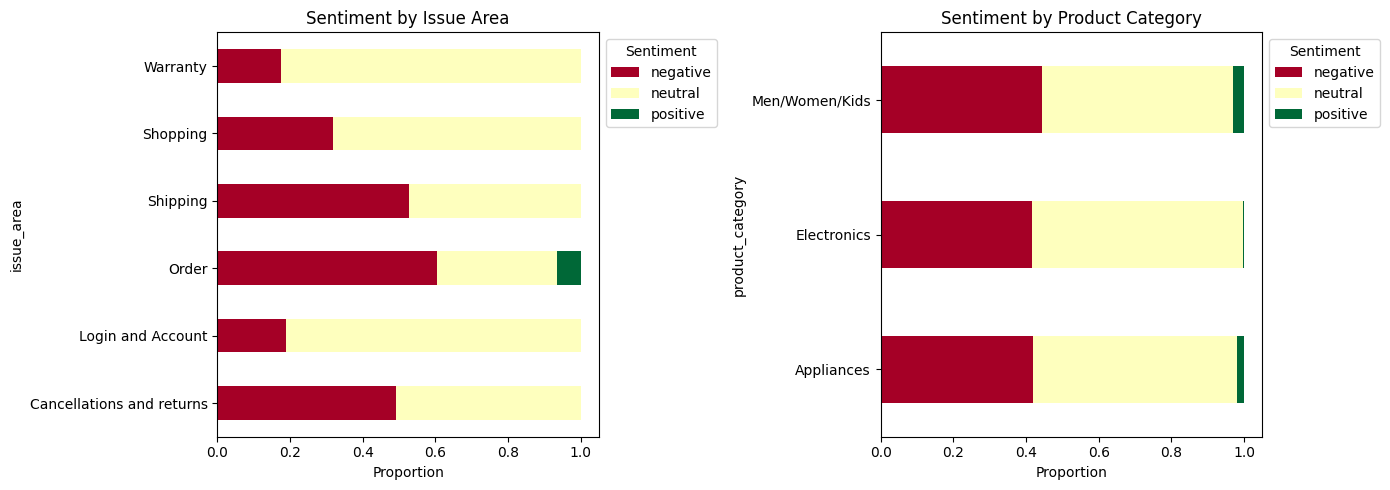

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.crosstab(train_df['issue_area'], train_df['customer_sentiment'], normalize='index').plot(
    kind='barh', stacked=True, ax=axes[0], colormap='RdYlGn'
)
axes[0].set_title('Sentiment by Issue Area')
axes[0].set_xlabel('Proportion')
axes[0].legend(title='Sentiment', bbox_to_anchor=(1.0, 1.0))

pd.crosstab(train_df['product_category'], train_df['customer_sentiment'], normalize='index').plot(
    kind='barh', stacked=True, ax=axes[1], colormap='RdYlGn'
)
axes[1].set_title('Sentiment by Product Category')
axes[1].set_xlabel('Proportion')
axes[1].legend(title='Sentiment', bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()

## 8. Conversation Structure Analysis
Analyzing turn count and who initiates the conversation (useful insight for the text feature).

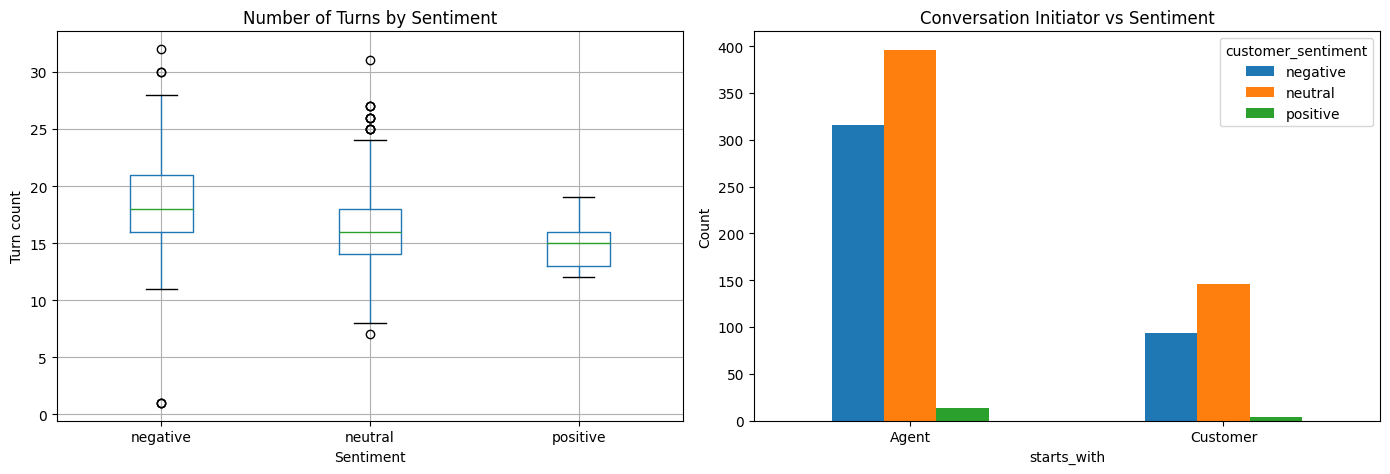

,Sentiment,Avg Turns,Std,Min,Median,Max
0,negative,18.4,3.8,1,18.0,32
1,neutral,16.3,3.3,7,16.0,31
2,positive,14.9,2.1,12,15.0,19


customer_sentiment,Initiator,negative,neutral,positive,All
0,Agent,316,396,13,725
1,Customer,94,146,4,244
2,All,410,542,17,969


In [11]:
# Number of turns (Agent: or Customer: markers)
train_df['num_turns'] = train_df['conversation'].str.count(r'(?:Agent:|Customer:)')
train_df['starts_with'] = train_df['conversation'].str.extract(r'^(Agent|Customer)')[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.boxplot(column='num_turns', by='customer_sentiment', ax=axes[0])
axes[0].set_title('Number of Turns by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Turn count')
plt.sca(axes[0])
plt.title('Number of Turns by Sentiment')

ct = pd.crosstab(train_df['starts_with'], train_df['customer_sentiment'])
ct.plot(kind='bar', ax=axes[1])
axes[1].set_title('Conversation Initiator vs Sentiment')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylabel('Count')

plt.suptitle('')
plt.tight_layout()
plt.show()

turns_table = train_df.groupby('customer_sentiment')['num_turns'].agg(['mean', 'std', 'min', 'median', 'max']).round(1)
turns_table.columns = ['Avg Turns', 'Std', 'Min', 'Median', 'Max']
turns_table.index.name = 'Sentiment'
display(turns_table.reset_index())

initiator_table = pd.crosstab(train_df['starts_with'], train_df['customer_sentiment'], margins=True)
initiator_table.index.name = 'Initiator'
display(initiator_table.reset_index())

## 9. Train vs Test Distribution Comparison
Checking for distribution shift between train and test sets (without leaking labels for training).

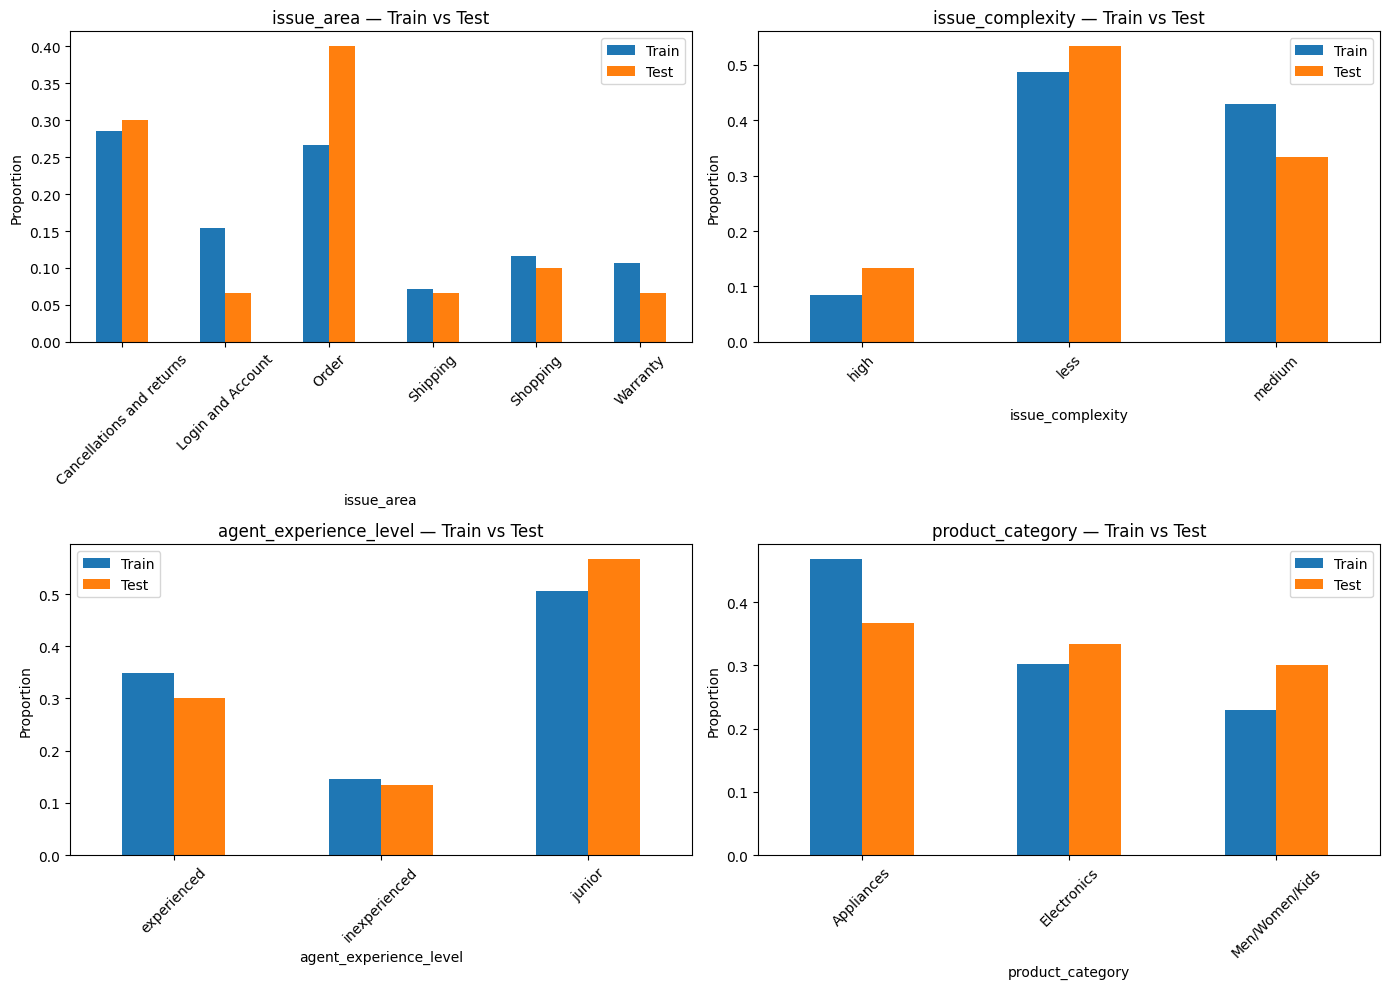

In [12]:
compare_cols = ['issue_area', 'issue_complexity', 'agent_experience_level', 'product_category']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, compare_cols):
    train_pct = train_df[col].value_counts(normalize=True).sort_index()
    test_pct = test_df[col].value_counts(normalize=True).sort_index()
    comp = pd.DataFrame({'Train': train_pct, 'Test': test_pct}).fillna(0)
    comp.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} — Train vs Test')
    ax.set_ylabel('Proportion')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Sample Conversations

In [13]:
for sentiment in train_df['customer_sentiment'].unique():
    sample = train_df[train_df['customer_sentiment'] == sentiment].iloc[0]
    print(f"{'='*80}")
    print(f"SENTIMENT: {sentiment.upper()}")
    print(f"Issue: {sample['issue_area']} > {sample['issue_category']}")
    print(f"Complexity: {sample['issue_complexity']} | Agent: {sample['agent_experience_level']}")
    print(f"-"*80)
    print(sample['conversation'][:500] + '...' if len(sample['conversation']) > 500 else sample['conversation'])
    print()

SENTIMENT: NEUTRAL
Issue: Login and Account > Mobile Number and Email Verification
Complexity: medium | Agent: junior
--------------------------------------------------------------------------------
Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?

Customer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG), but I'm unable to proceed as it's asking for mobile number or email verification. Can you help me with that?

Agent: Sure, I can assist you with that. May I know your registered mobile number or email address, please?

Customer: My registered mobile number is +1 123-456-7890.

Agent: Thank you. Let me ch...

SENTIMENT: NEGATIVE
Issue: Order > Order Delivery Issues
Complexity: medium | Agent: experienced
--------------------------------------------------------------------------------
Agent: Thank you for contacting BrownBox customer support. My name is Sarah. How can I assist you today?

Customer: Hi